# 03 - Khai Phá Tri Thức: Luật Kết Hợp & Phân Cụm

**Mục tiêu:**
- Áp dụng Apriori tìm luật kết hợp liên quan bệnh tim
- Phân cụm KMeans & Hierarchical
- Xác định số cụm tối ưu
- Mô tả đặc điểm từng cụm nguy cơ

In [1]:
import sys
sys.path.insert(0, '..')
import os
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

from src.data.loader import load_params
params = load_params()
seed = params['seed']

## 3.1 Luật Kết Hợp (Association Rule Mining - Apriori)

In [2]:
# Load dữ liệu đã rời rạc hoá
df_disc = pd.read_csv(params['paths']['discretized_data'])
print(f"Shape: {df_disc.shape}")
print(f"Columns: {list(df_disc.columns)}")
df_disc.head()

Shape: (920, 34)
Columns: ['age_young', 'age_middle', 'age_senior', 'age_elderly', 'is_male', 'cp_typical_angina', 'cp_asymptomatic', 'cp_non-anginal', 'cp_atypical_angina', 'bp_normal', 'bp_elevated', 'bp_high', 'chol_normal', 'chol_borderline', 'chol_high', 'fbs_high', 'ecg_normal', 'ecg_abnormal', 'hr_low', 'hr_normal', 'hr_high', 'exercise_angina', 'oldpeak_zero', 'oldpeak_low', 'oldpeak_high', 'slope_downsloping', 'slope_flat', 'slope_upsloping', 'ca_zero', 'ca_positive', 'thal_normal', 'thal_fixed_defect', 'thal_reversable', 'heart_disease']


,age_young,age_middle,age_senior,age_elderly,is_male,cp_typical_angina,cp_asymptomatic,cp_non-anginal,cp_atypical_angina,bp_normal,...,oldpeak_high,slope_downsloping,slope_flat,slope_upsloping,ca_zero,ca_positive,thal_normal,thal_fixed_defect,thal_reversable,heart_disease
0,0,0,1,0,1,1,0,0,0,0,...,1,1,0,0,1,0,0,1,0,0
1,0,0,0,1,1,0,1,0,0,0,...,0,0,1,0,0,1,1,0,0,1
2,0,0,0,1,1,0,1,0,0,0,...,1,0,1,0,0,1,0,0,1,1
3,1,0,0,0,1,0,0,1,0,0,...,1,1,0,0,1,0,1,0,0,0
4,0,1,0,0,0,0,0,0,1,0,...,0,0,0,1,1,0,1,0,0,0


In [3]:
from src.mining.association import run_apriori, format_rules_table, interpret_rules

freq_items, rules, rules_heart = run_apriori(
    df_disc,
    min_support=params['apriori']['min_support'],
    min_confidence=params['apriori']['min_confidence'],
    min_lift=params['apriori']['min_lift'],
)

🔗 ASSOCIATION RULE MINING (Apriori)

--- Finding frequent itemsets (min_support=0.08)...
✅ Found 715 frequent itemsets

--- Generating rules (min_confidence=0.5)...
✅ Generated 832 rules (lift >= 1.2)
✅ 349 rules related to 'heart_disease'


C:\Users\xuang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [4]:
# Top frequent itemsets
print("Top 15 Frequent Itemsets:")
freq_items.head(15)

Top 15 Frequent Itemsets:


,support,itemsets
4,0.789130,(is_male)
14,0.598913,(ecg_normal)
28,0.553261,(heart_disease)
5,0.539130,(cp_asymptomatic)
91,0.498913,"(is_male, heart_disease)"
17,0.494565,(hr_normal)
77,0.469565,"(is_male, ecg_normal)"
68,0.463043,"(is_male, cp_asymptomatic)"
109,0.426087,"(cp_asymptomatic, heart_disease)"
1,0.426087,(age_middle)


In [5]:
# Luật kết hợp liên quan bệnh tim
rules_table = format_rules_table(rules_heart, top_n=15)
rules_table

,antecedents,consequents,support,confidence,lift
0,"thal_reversable, slope_flat, cp_asymptomatic",heart_disease,0.0859,0.9753,1.7628
1,"is_male, oldpeak_high, slope_flat, cp_asymptom...",heart_disease,0.0859,0.9634,1.7413
2,"oldpeak_high, slope_flat, cp_asymptomatic",heart_disease,0.0946,0.9560,1.7280
3,"bp_high, slope_flat, cp_asymptomatic, is_male",heart_disease,0.0859,0.9518,1.7204
4,"is_male, oldpeak_high, cp_asymptomatic",heart_disease,0.1217,0.9412,1.7011
5,"hr_low, slope_flat, cp_asymptomatic",heart_disease,0.0859,0.9405,1.6999
6,"slope_flat, chol_normal, cp_asymptomatic",heart_disease,0.0826,0.9383,1.6959
7,"ca_positive, cp_asymptomatic",heart_disease,0.0815,0.9375,1.6945
8,"is_male, oldpeak_high, slope_flat",heart_disease,0.1065,0.9333,1.6870
9,"oldpeak_high, cp_asymptomatic",heart_disease,0.1348,0.9323,1.6852


In [6]:
# Diễn giải luật theo ý nghĩa y học
interpretations = interpret_rules(rules_heart, top_n=10)
for interp in interpretations:
    print(interp)
    print()

Luật 1: Nếu thal_reversable, slope_flat, cp_asymptomatic → Nguy cơ bệnh tim
  • Confidence: 97.5% (≈ 98% bệnh nhân với đặc điểm này bị bệnh tim)
  • Lift: 1.76 (nguy cơ cao gấp 1.8 lần so với trung bình)
  • Support: 8.6% (xuất hiện trong 8.6% dataset)

Luật 2: Nếu is_male, oldpeak_high, slope_flat, cp_asymptomatic → Nguy cơ bệnh tim
  • Confidence: 96.3% (≈ 96% bệnh nhân với đặc điểm này bị bệnh tim)
  • Lift: 1.74 (nguy cơ cao gấp 1.7 lần so với trung bình)
  • Support: 8.6% (xuất hiện trong 8.6% dataset)

Luật 3: Nếu oldpeak_high, slope_flat, cp_asymptomatic → Nguy cơ bệnh tim
  • Confidence: 95.6% (≈ 96% bệnh nhân với đặc điểm này bị bệnh tim)
  • Lift: 1.73 (nguy cơ cao gấp 1.7 lần so với trung bình)
  • Support: 9.5% (xuất hiện trong 9.5% dataset)

Luật 4: Nếu bp_high, slope_flat, cp_asymptomatic, is_male → Nguy cơ bệnh tim
  • Confidence: 95.2% (≈ 95% bệnh nhân với đặc điểm này bị bệnh tim)
  • Lift: 1.72 (nguy cơ cao gấp 1.7 lần so với trung bình)
  • Support: 8.6% (xuất hiện t

In [7]:
# Lưu kết quả
from src.evaluation.report import save_rules_table
if len(rules_table) > 0:
    save_rules_table(rules_table, 'association_rules_heart')

💾 Saved table: outputs/tables\association_rules_heart.csv


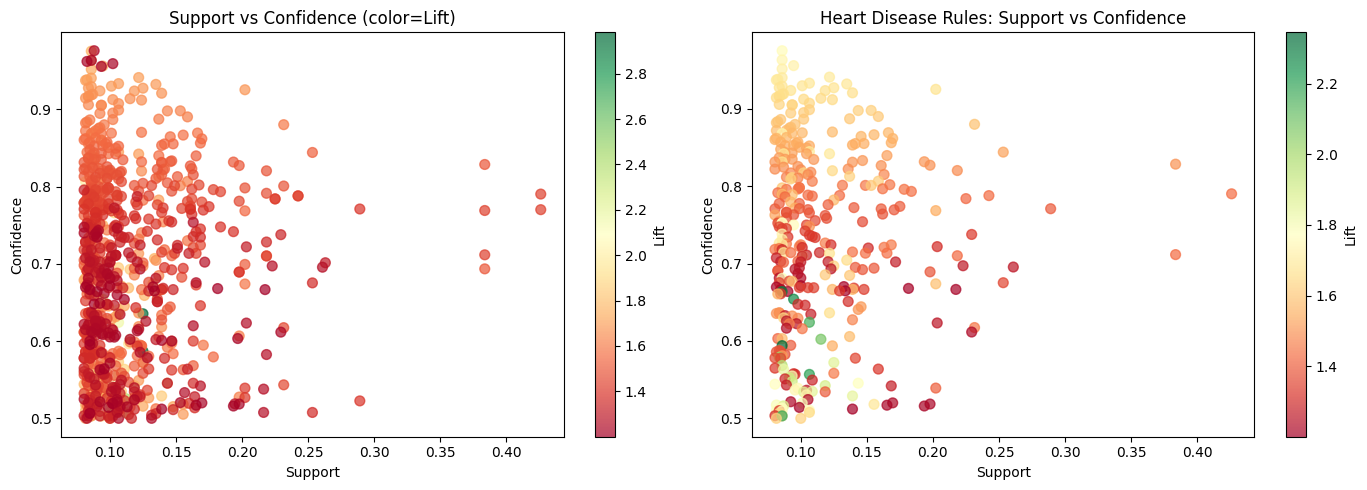

In [8]:
# Visualize: Support vs Confidence
if len(rules) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].scatter(rules['support'], rules['confidence'], 
                    c=rules['lift'], cmap='RdYlGn', alpha=0.7, s=50)
    axes[0].set_xlabel('Support')
    axes[0].set_ylabel('Confidence')
    axes[0].set_title('Support vs Confidence (color=Lift)')
    plt.colorbar(axes[0].collections[0], ax=axes[0], label='Lift')
    
    if len(rules_heart) > 0:
        axes[1].scatter(rules_heart['support'], rules_heart['confidence'],
                        c=rules_heart['lift'], cmap='RdYlGn', alpha=0.7, s=50)
        axes[1].set_xlabel('Support')
        axes[1].set_ylabel('Confidence')
        axes[1].set_title('Heart Disease Rules: Support vs Confidence')
        plt.colorbar(axes[1].collections[0], ax=axes[1], label='Lift')
    
    plt.tight_layout()
    plt.savefig('outputs/figures/association_rules.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3.2 Phân Cụm (Clustering)

In [9]:
# Load processed data
df_clean = pd.read_csv(params['paths']['processed_data'])

from src.features.builder import select_features_for_modeling
X, y = select_features_for_modeling(df_clean)

# Chuẩn hoá
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"X_scaled shape: {X_scaled.shape}")

✅ X shape: (918, 13), y shape: (918,)
   Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
   Target distribution: {1: np.int64(508), 0: np.int64(410)}
X_scaled shape: (918, 13)


### 3.2.1 Tìm số cụm tối ưu (Elbow + Silhouette)

In [10]:
from src.mining.clustering import find_optimal_k
from src.visualization.plots import plot_elbow_silhouette

k_range = range(params['clustering']['k_range_min'], params['clustering']['k_range_max'] + 1)
k_results = find_optimal_k(X_scaled, k_range, seed)

📊 FINDING OPTIMAL K
   k=2: Inertia=10318.7, Silhouette=0.1438, DBI=2.4313
   k=3: Inertia=9461.8, Silhouette=0.1426, DBI=2.1637
   k=4: Inertia=8740.2, Silhouette=0.1533, DBI=2.0035
   k=5: Inertia=8156.9, Silhouette=0.1392, DBI=1.9775
   k=6: Inertia=7701.4, Silhouette=0.1346, DBI=1.9689
   k=7: Inertia=7425.7, Silhouette=0.1195, DBI=1.9959
   k=8: Inertia=7192.7, Silhouette=0.1188, DBI=1.9917
   k=9: Inertia=7055.6, Silhouette=0.1268, DBI=2.1453
   k=10: Inertia=6825.1, Silhouette=0.1194, DBI=1.9886

✅ Best k = 4 (Silhouette = 0.1533, DBI = 2.0035)


💾 Saved: outputs/figures\elbow_silhouette.png


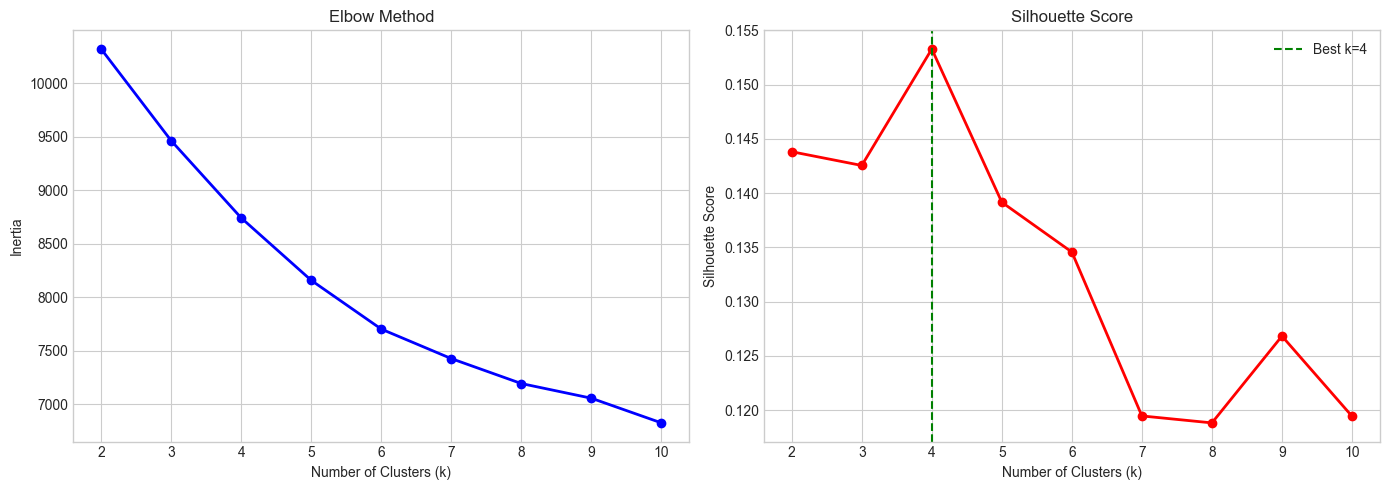

In [11]:
fig = plot_elbow_silhouette(k_results['k_range'], k_results['inertias'], k_results['silhouettes'])
plt.show()

### 3.2.2 KMeans Clustering

In [12]:
from src.mining.clustering import run_kmeans, profile_clusters, get_cluster_insights

best_k = k_results['best_k']
kmeans_labels, kmeans_model, kmeans_sil, kmeans_dbi = run_kmeans(X_scaled, best_k, seed)


🔵 Running KMeans (k=4)...
   Silhouette Score: 0.1533
   Davies-Bouldin Index: 2.0035
   Cluster 0: 124 samples (13.5%)
   Cluster 1: 309 samples (33.7%)
   Cluster 2: 89 samples (9.7%)
   Cluster 3: 396 samples (43.1%)


In [13]:
# Profile clusters
profile = profile_clusters(df_clean, kmeans_labels)


📋 CLUSTER PROFILES:
--------------------------------------------------

  Cluster 0: 124 patients (13.5%)
  → Tỷ lệ bệnh tim: 66.9%
  ⚠️  NHÓM NGUY CƠ CAO!

  Cluster 1: 309 patients (33.7%)
  → Tỷ lệ bệnh tim: 82.8%
  ⚠️  NHÓM NGUY CƠ CAO!

  Cluster 2: 89 patients (9.7%)
  → Tỷ lệ bệnh tim: 84.3%
  ⚠️  NHÓM NGUY CƠ CAO!

  Cluster 3: 396 patients (43.1%)
  → Tỷ lệ bệnh tim: 23.7%
  ✅ Nhóm nguy cơ thấp


In [14]:
# Cluster insights
insights = get_cluster_insights(df_clean, kmeans_labels)
for insight in insights:
    print(insight)

Cụm 0 (124 bệnh nhân, 67% bệnh tim): Đặc trưng bởi age cao
Cụm 1 (309 bệnh nhân, 83% bệnh tim): Đặc trưng bởi cp thấp, thalch thấp
Cụm 2 (89 bệnh nhân, 84% bệnh tim): Đặc trưng bởi age cao, restecg thấp, oldpeak cao, ca cao, thal cao
Cụm 3 (396 bệnh nhân, 24% bệnh tim): Đặc trưng bởi age thấp, thalch cao


### 3.2.3 Hierarchical Clustering

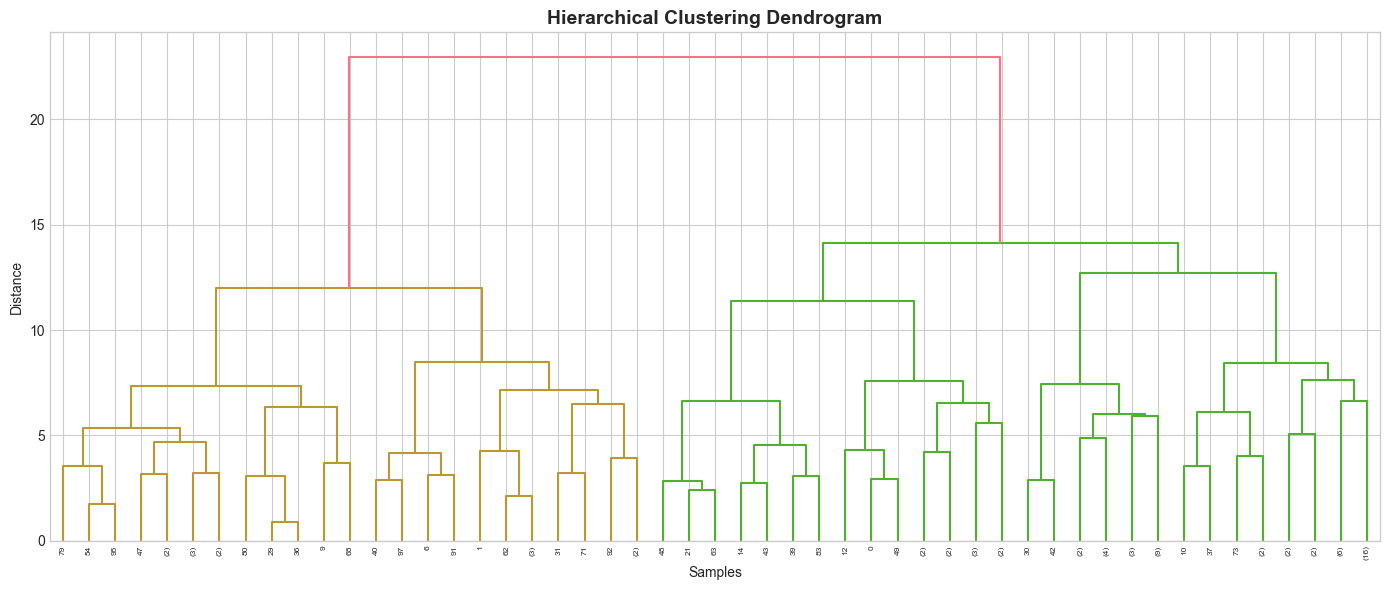

In [15]:
from src.mining.clustering import run_hierarchical
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled[:100], method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, truncate_mode='level', p=5)
ax.set_title('Hierarchical Clustering Dendrogram', fontsize=14, fontweight='bold')
ax.set_xlabel('Samples')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig('outputs/figures/dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
hier_labels, hier_model, hier_sil, hier_dbi = run_hierarchical(X_scaled, best_k)

print(f"\n=== SO SÁNH CLUSTERING ===")
comparison_df = pd.DataFrame({
    'KMeans': [kmeans_sil, kmeans_dbi],
    'Hierarchical': [hier_sil, hier_dbi]
}, index=['Silhouette Score (cao=tốt)', 'Davies-Bouldin Index (thấp=tốt)'])
print(comparison_df.round(4))


🟢 Running Hierarchical Clustering (k=4, linkage=ward)...
   Silhouette Score: 0.1359
   Davies-Bouldin Index: 2.0980
   Cluster 0: 456 samples (49.7%)
   Cluster 1: 265 samples (28.9%)
   Cluster 2: 82 samples (8.9%)
   Cluster 3: 115 samples (12.5%)

=== SO SÁNH CLUSTERING ===
                                 KMeans  Hierarchical
Silhouette Score (cao=tốt)       0.1533        0.1359
Davies-Bouldin Index (thấp=tốt)  2.0035        2.0980


### 3.2.4 Visualization Clusters

💾 Saved: outputs/figures\cluster_profiles.png


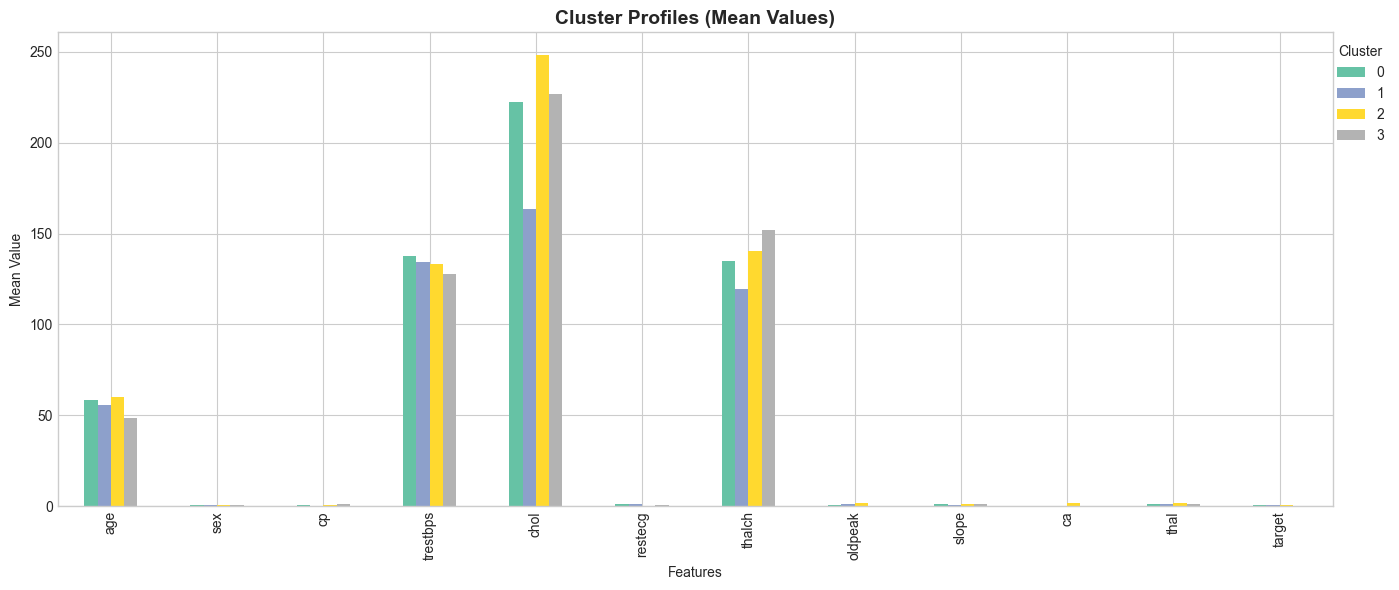

In [17]:
from src.visualization.plots import plot_cluster_profiles

df_cluster = df_clean.copy()
df_cluster['cluster'] = kmeans_labels

fig = plot_cluster_profiles(df_cluster)
plt.show()

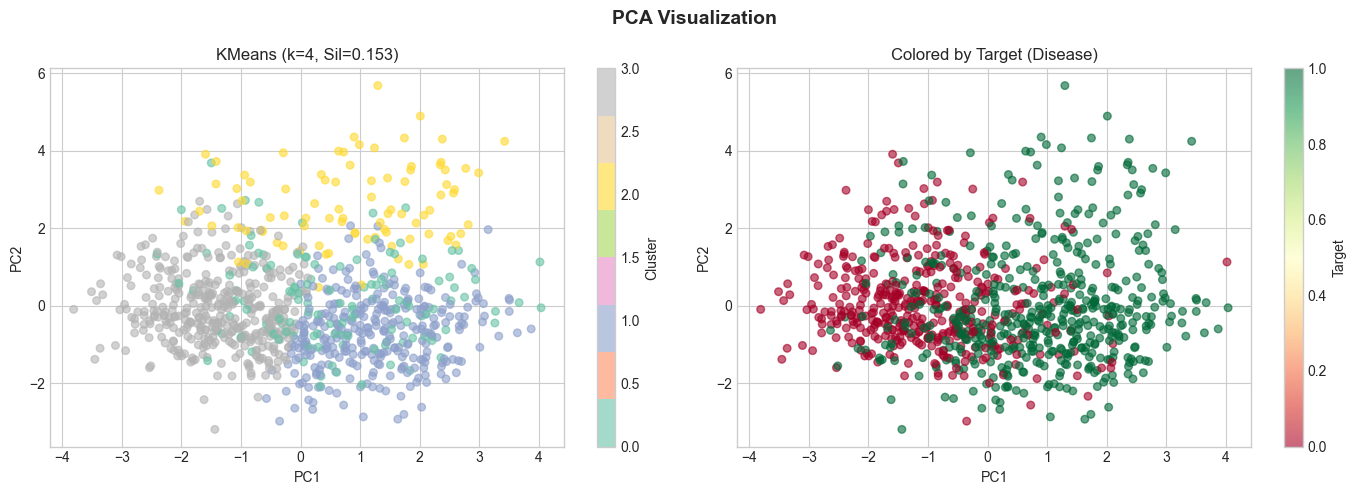

In [18]:
# Scatter plot 2D (PCA)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KMeans
scatter1 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap='Set2', alpha=0.6, s=30)
axes[0].set_title(f'KMeans (k={best_k}, Sil={kmeans_sil:.3f})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# By target
scatter2 = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='RdYlGn', alpha=0.6, s=30)
axes[1].set_title('Colored by Target (Disease)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1], label='Target')

plt.suptitle('PCA Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.3 Nhận xét

**Luật kết hợp:**
- Apriori tìm được các tổ hợp triệu chứng liên quan bệnh tim
- Các yếu tố xuất hiện nhiều: đau ngực không triệu chứng, ST depression, cholesterol cao

**Phân cụm:**
- Số cụm tối ưu xác định bằng Silhouette Score
- Mỗi cụm có đặc trưng và tỷ lệ bệnh khác nhau
- Nhóm nguy cơ cao được xác định rõ ràng